# Quickstart

## Packages

Note: To run the spatial analysis at the end of this tutorial you will need to install ParTIpy with the tutorial extras: `pip install partipy[extra]`.

In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import plotnine as pn
import decoupler as dc
import numpy as np
from scipy.spatial.distance import cdist

import partipy as pt

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Note: Importing `partipy` for the first time after installing might take some time (~30s) because `numba` needs to compile some code in the background. After that, it'll be quick!

## Data

First, we need to load and cache a single-cell dataset. In this example, we use mouse hepatocytes profiled by scRNA-seq from {cite:p}`benMoshe2022`. We downloaded the raw data from [Zenodo](https://zenodo.org/records/6035873) and saved it to [figshare](https://figshare.com/articles/dataset/scRNA-seq_hepatocyte_data_from_Ben-Moshe_et_al_2022_/30588713?file=59459459) for convenient access in this tutorial.

In [2]:
adata = sc.read("data/hepatocyte_processed.h5ad", backup_url="https://figshare.com/ndownloader/files/59459459")
adata

AnnData object with n_obs × n_vars = 1999 × 8354
    obs: 'cell_type', 'zone', 'run_id', 'time_point', 'UMAP_X', 'UMAP_Y'

## Preprocessing

Before conducting archetypal analysis (AA) on single-cell RNA-seq data, it is beneficial to reduce the dimensionality of the data, as this helps remove noise and substantially increases the computational efficiency of AA.
To achieve this, we first scale the counts across all cells to a common value using `sc.pp.normalize_total`, followed by logarithmic normalization with `sc.pp.log1p`.  
By default, `normalize_total` scales each cell to the median total counts across all cells, which preserves the typical range of expression values prior to logarithmic transformation.  

Next, we identify highly variable genes and apply principal component analysis (PCA) using only these genes.  
All preprocessing steps are performed using functions from the `scanpy` package.

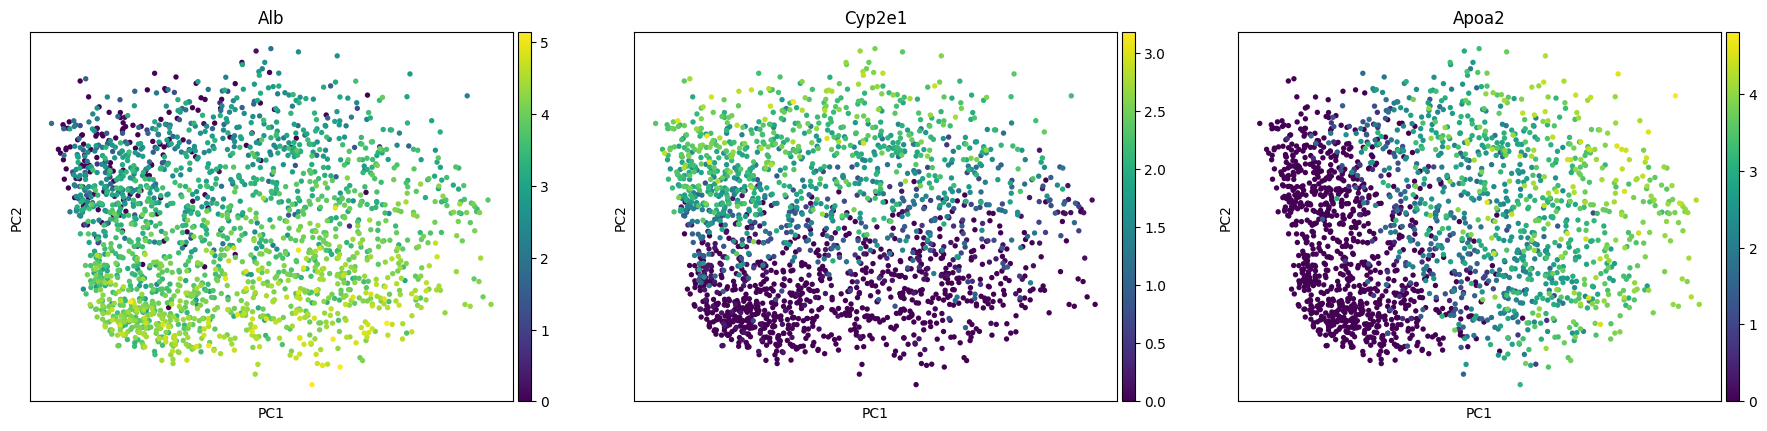

In [3]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable")
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10, copy=True)
sc.pl.pca_scatter(adata, color=["Alb", "Cyp2e1", "Apoa2"])

To determine the number of principal components to use for fitting the archetypes, we will examine the scree plot from the PCA. Additionally the plot shows the variance explained if we shuffle the data before computing the PCA. This plot indicates that we should only use the first three principal components.

100%|██████████| 50/50 [00:04<00:00, 10.97it/s]


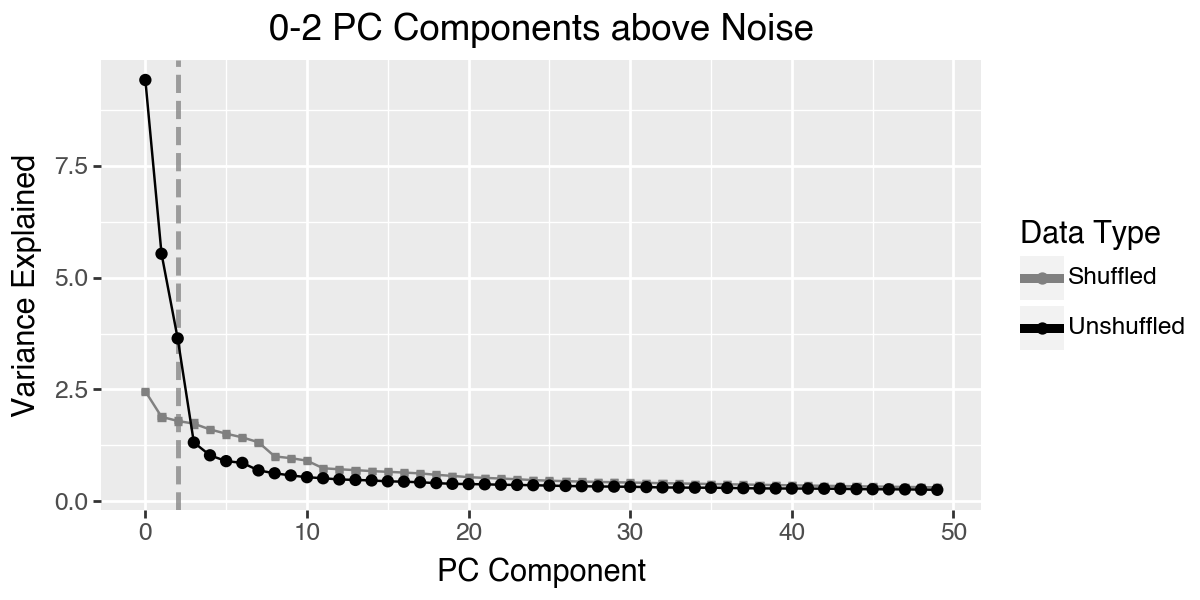

In [4]:
pt.compute_shuffled_pca(adata, mask_var="highly_variable")
pt.plot_shuffled_pca(adata)

We store this setting in the adata.uns slot using the utility function `set_obsm`. Using `n_dimensions=3` is equivalent to specifiy `n_dimensions=[0, 1, 2]`. If you do not want to use the first princial component, for example because it captures some technical effect, then you can simply specify `n_dimensions=[1, 2]`.

In [5]:
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=3)

## Choosing the Number of Archetypes

Now, we are ready to perform archetypal analysis, but the key question remains: how many archetypes should be used?

There is no definitive ground truth for this choice, but several heuristics can guide the decision. One approach is to evaluate how much variance is explained by different numbers of archetypes.

The function `var_explained_aa()` takes the reduced PCA data and computes the explained variance across a range of archetypes (from `min_k` to `max_k`). By default, this function utilizes all available CPU cores, as indicated by the `n_jobs` argument, which is set to `-1`.

Additionally the function `var_explained_aa()` computes an information criteria which was suggested by Suleman, A., 2017. Validation of archetypal analysis, in: 2017 IEEE International Conference on Fuzzy Systems (FUZZ-IEEE) pp. 1–6. https://doi.org/10.1109/FUZZ-IEEE.2017.8015385


The results are stored in `adata.uns["AA_metrics"]` and can be effectively visualized using plot_var_explained_aa(). The plot suggests that a reasonable choice for the number of archetypes is 4 as the additional explained variance becomes negligible beyond this point.

In [6]:
adata

AnnData object with n_obs × n_vars = 1999 × 8354
    obs: 'cell_type', 'zone', 'run_id', 'time_point', 'UMAP_X', 'UMAP_Y'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'AA_pca', 'AA_config'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'z_scaled'

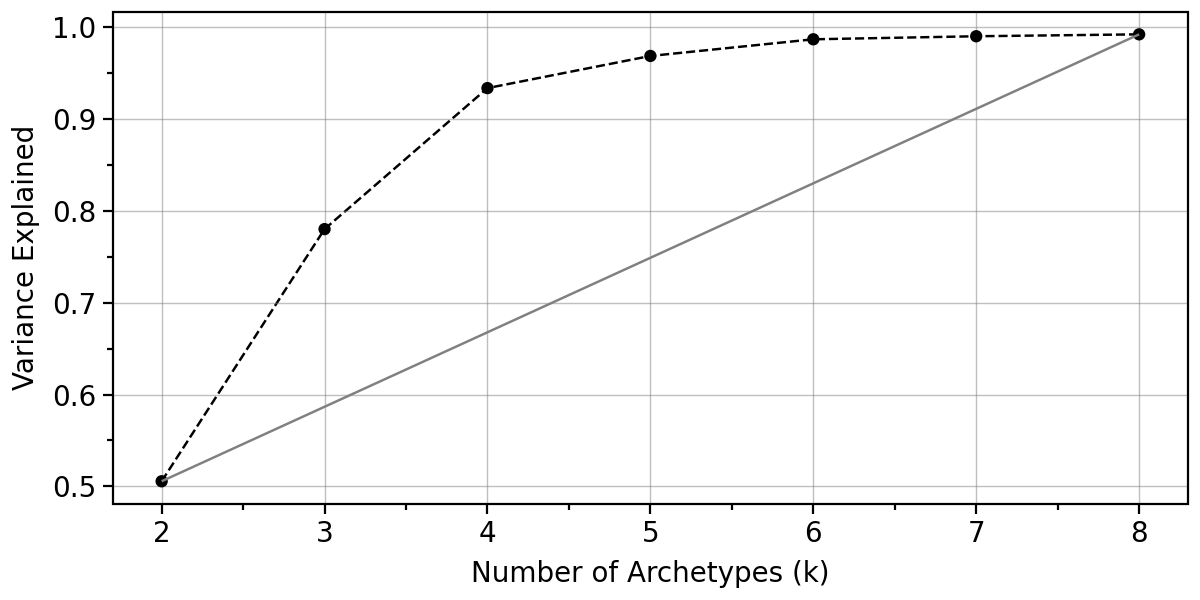

In [7]:
pt.compute_selection_metrics(adata=adata, n_archetypes_list=range(2, 9))
pt.plot_var_explained(adata)

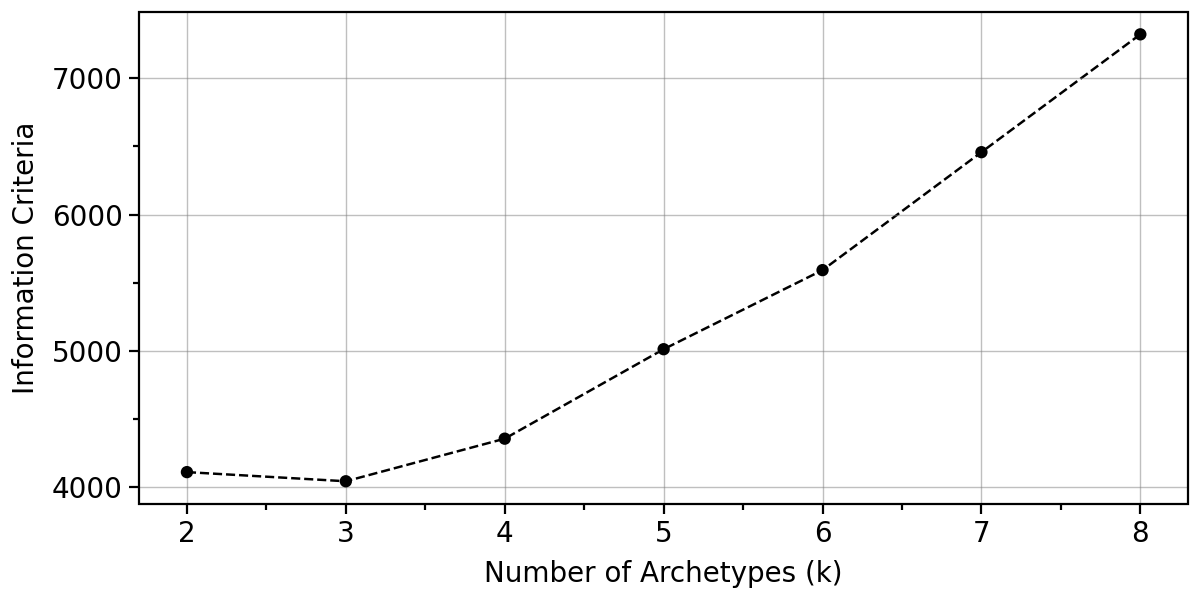

In [8]:
pt.plot_IC(adata)

An important consideration is whether the positions of the archetypes remain stable for a given number of archetypes. To assess this, we apply bootstrapping and perform Archetypal Analysis (AA) on resampled datasets.

By default, this function utilizes all available CPU cores, as specified by the `n_jobs` argument, which is set to `-1`. The results are stored in `adata.uns["AA_bootstrap"]` and can be visualized using `pt.plot_bootstrap_variance(adata)`.

As hinted to above, this result also suggest that 4 archetypes are highly stable.

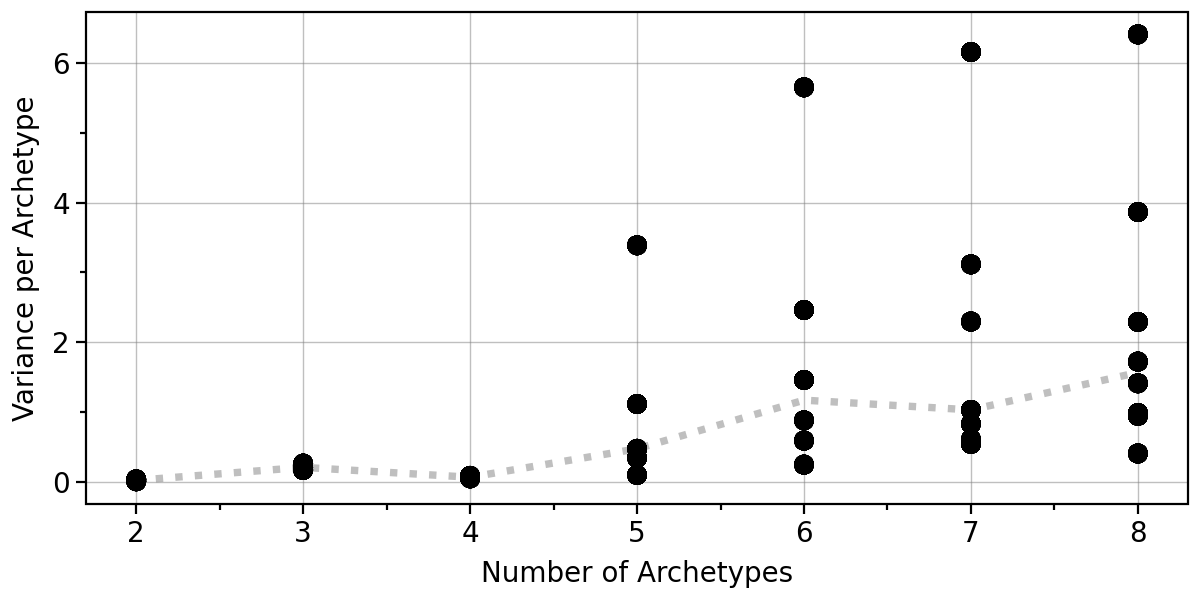

In [9]:
pt.compute_bootstrap_variance(adata=adata, n_bootstrap=50, n_archetypes_list=range(2, 9))
pt.plot_bootstrap_variance(adata)

## Archetypal Analysis

To compute the archetypes, we can simply use the `compute_archetypes` function. There are many optimization parameters which we describe in more detail in the vignette about [Archetypal Analysis](https://partipy.readthedocs.io/en/latest/notebooks/archetypal_analysis.html). We only briefly demonstrate how results from archetypal analysis can be incorporated when varying parameters, using the delta parameter as an example.

To get a feeling for the archetypes we might plot the polytope on first two dimensions. However, note that we actually fitted the polytope in a higher dimensional space.

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='optim_kwargs', input_value=(), input_type=tuple])


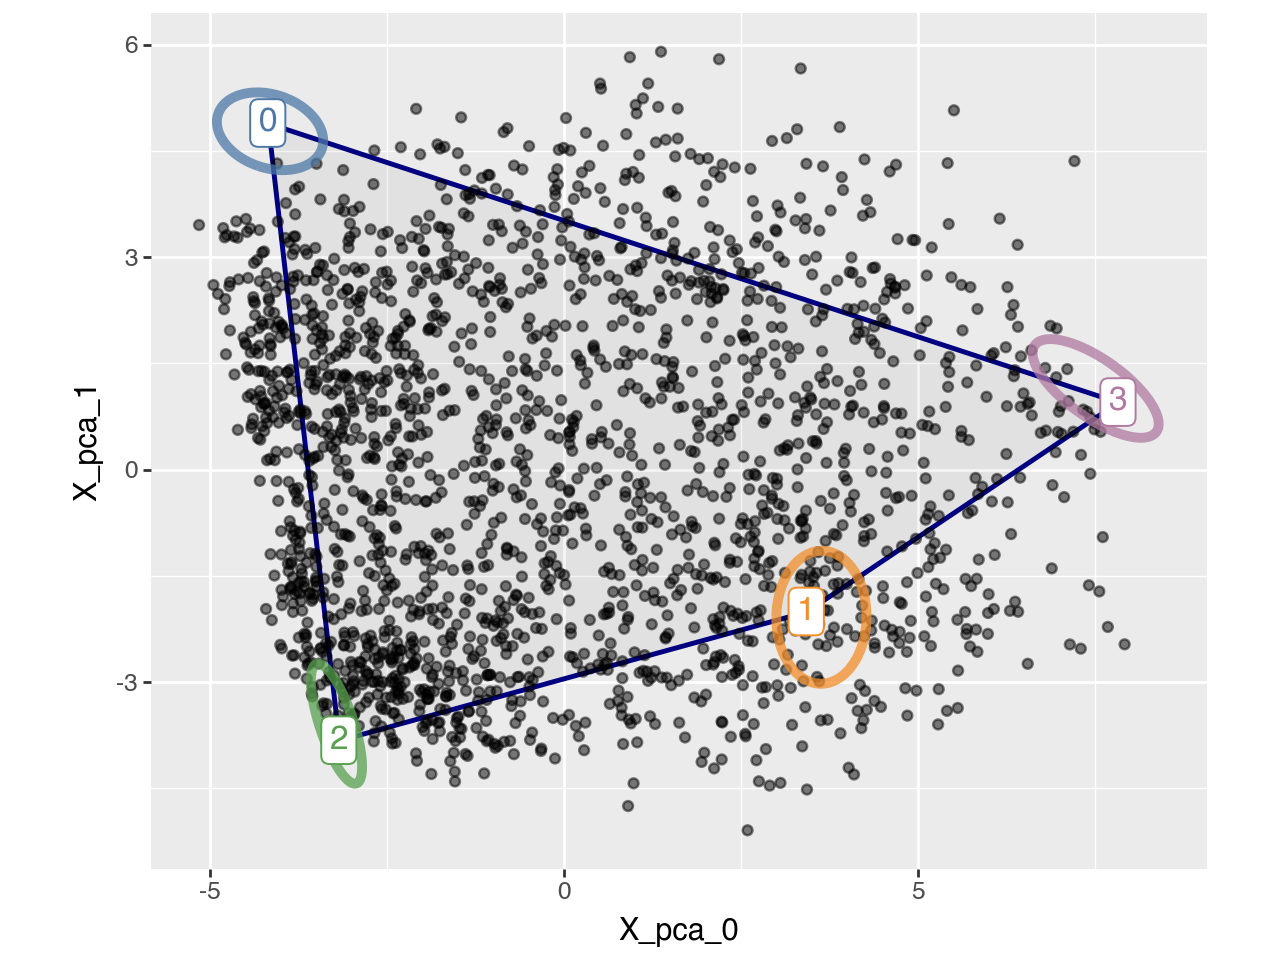

In [10]:
#pt.compute_archetypes(adata, n_archetypes=4, archetypes_only=False)
pt.plot_archetypes_2D(adata=adata, show_contours=True, result_filters={"n_archetypes": 4, "delta": 0.0})

When only a few cells are sampled near the boundaries of the true phenotypic space, the convex hull of the observed data may underestimate the full range of variation. Such limited sampling can occur, for example, when the sample size is small or when the population is dominated by generalist cells rather than task-specialized ones. In these cases, relaxing the convexity constraint can help recover the true archetypes. This is achieved by introducing a relaxation parameter `delta` (see Equation 2 in the [preprint](https://www.biorxiv.org/content/10.1101/2025.09.08.674797v1)), where larger `delta` values allow archetypes to lie farther from the data cloud (see Supplementary Figure S1 in the [preprint](https://www.biorxiv.org/content/10.1101/2025.09.08.674797v1)). This approach has been used in {cite:p}`Korem2015` and subsequent works. The corresponding plot for `delta=0.5` is shown below.

Whenever multiple archetypal analysis results are stored in `adata.uns["AA_results"]`, the `result_filters` dictionary must be used to uniquely identify which result (e.g., combination of `n_archetypes` and `delta`) to visualize or analyze. This argument is consistently required in all subsequent functions.

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='optim_kwargs', input_value=(), input_type=tuple])


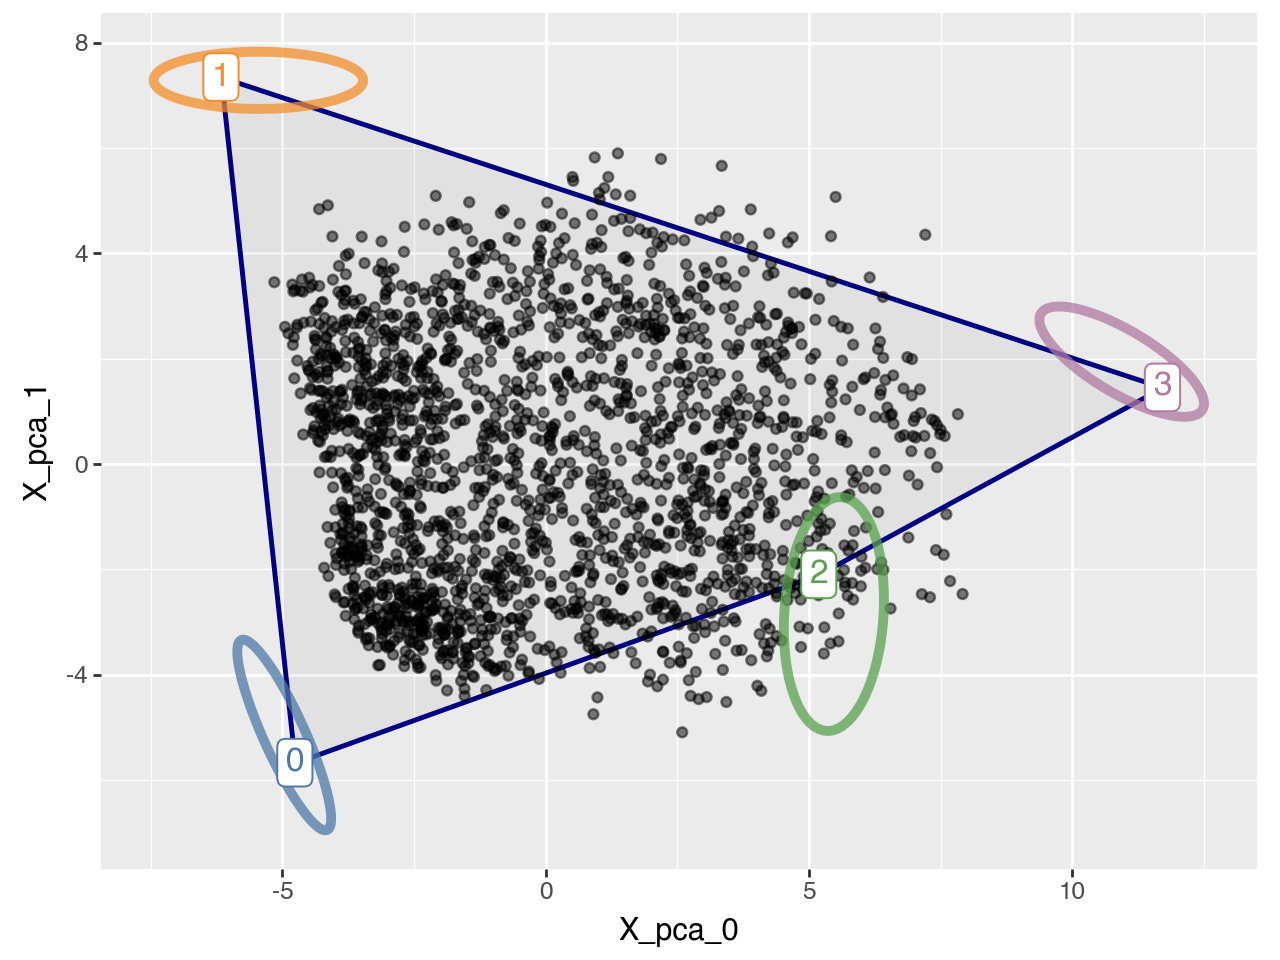

In [11]:
#pt.compute_archetypes(adata, n_archetypes=4, delta=0.5, archetypes_only=False)
pt.compute_bootstrap_variance(adata=adata, n_bootstrap=50, n_archetypes_list=[4], delta=0.5)
pt.plot_archetypes_2D(adata=adata, show_contours=True, result_filters={"n_archetypes": 4, "delta": 0.5})

For simplicity in this quickstart example, we will continue using `delta = 0.0.`

For a given $k$ we can also visually asses the bootstrap stability using `pt.plot_bootstrap_2D(adata)` for the first two principal components and `pt.plot_bootstrap_3D(adata)` for the first three.

Since Plotly does not render properly when exporting Jupyter notebooks, we will use only the 2D scatter plot here.

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `dict[str, any]` - serialized value may not be as expected [field_name='optim_kwargs', input_value=(), input_type=tuple])


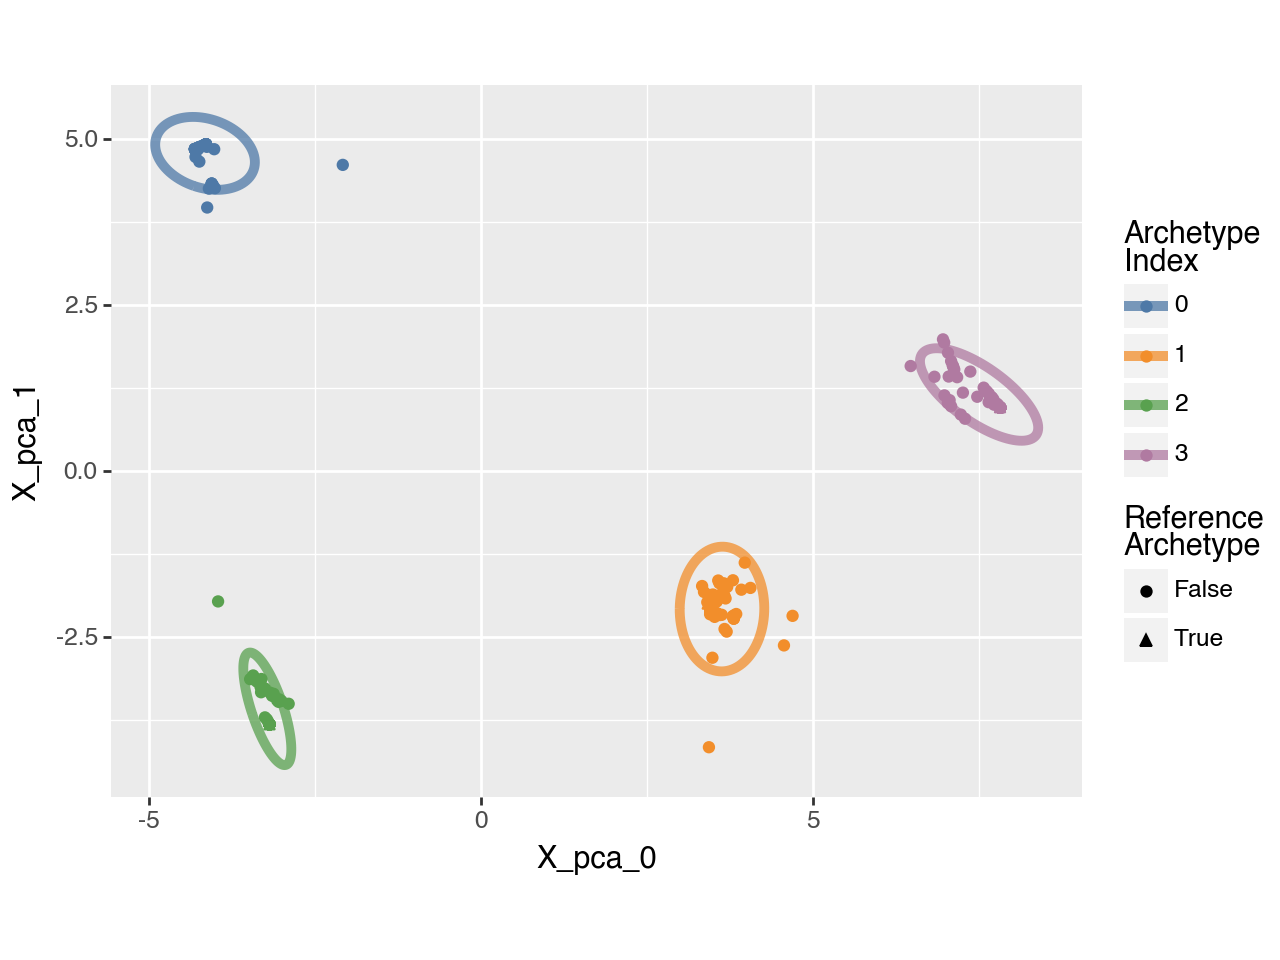

In [12]:
#pt.plot_bootstrap_3D(adata, result_filters={"n_archetypes": 4})
pt.plot_bootstrap_2D(adata, result_filters={"n_archetypes": 4, "delta": 0.0})

We can assess statistical significance by permuting the principal component (PC) coordinates and evaluating whether the polytope fit is worse on the permuted data than on the original data. To quantify the goodness of fit, we can use the residual sum of squares (RSS), which yields a p-value of 0.0 in this case. Alternatively, we can use the ratio between the volume of the convex hull of the archetypes and that of the data, and assess whether this ratio is closer to 1 for the original data than for the permuted data. In this case, the resulting p-value is 0.13.

In [13]:
significance = pt.t_ratio_significance(adata, result_filters={"n_archetypes": 4, "delta": 0.0})
significance

Randomizing: 100%|██████████| 100/100 [00:01<00:00, 60.14it/s]


{'t_ratio_p_value': np.float64(0.13), 'rss_p_value': np.float64(0.0)}

Below, we will focus on the archetype that is enriched in detoxification functions.

In [14]:
arch_idx = 0

## Characterizing Archetypes

To better understand the archetypes, we aim to obtain the characteristic gene expression profile for each one.

We begin by computing the archetypal weights using the `compute_archetype_weights()` function, which assigns each cell a weight for each archetype based on its proximity to the archetype in the reduced space.

Next, we generate a the characteristic expression profile for each archetype using weighted averaging. This is achieved with the `compute_archetype_expression()` function, which aggregates expression data across cells according to their archetypal contributions.

To better illustrate this, we visualize the weights for archetype **0**  using the `plot_2D_adata()` function, highlighting the extent to which each cell is associated with it.

Applied length scale is 3.25.


/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


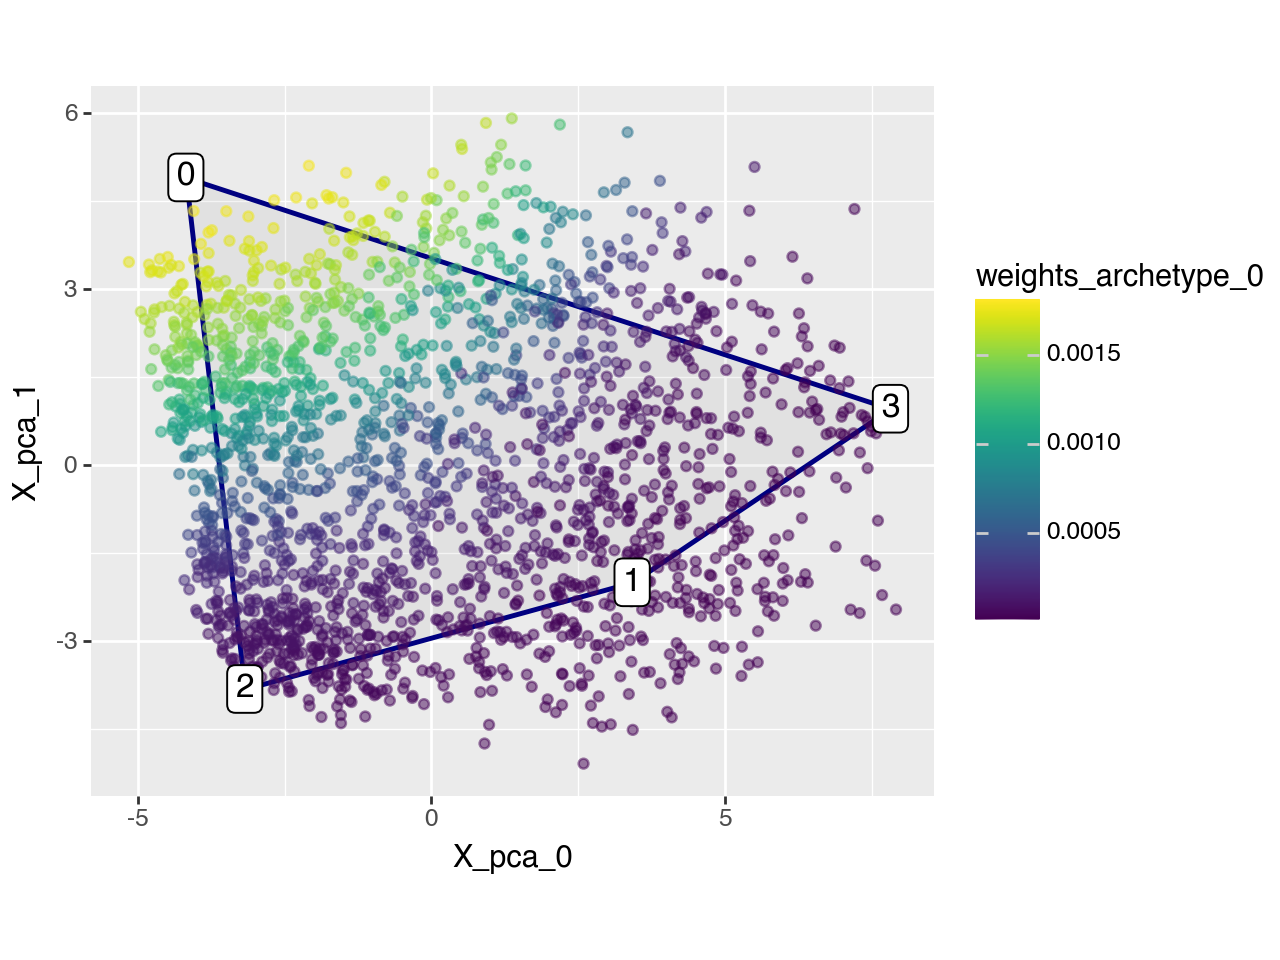

In [15]:
pt.compute_archetype_weights(adata=adata, mode="automatic", result_filters={"n_archetypes": 4, "delta": 0.0})
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled", result_filters={"n_archetypes": 4, "delta": 0.0})

adata.obs[f"weights_archetype_{arch_idx}"] = pt.get_aa_cell_weights(adata, n_archetypes=4, delta=0.0)[:, arch_idx]
pt.plot_archetypes_2D(adata=adata, color=f"weights_archetype_{arch_idx}", result_filters={"n_archetypes": 4, "delta": 0.0})

Now we can use the characteristic gene expression profile to see which genes are relatively important for each archetype. As promised above, archetype 0 is characterized by high expression of Cytochrome P450 enzymes which are important for detoxification.

In [16]:
archetype_expression.T.sort_values(arch_idx, ascending=False).head(10)

,0,1,2,3
Cyp2e1,0.818915,-0.077033,-0.487465,-0.128230
Cyp2c29,0.686523,0.045728,-0.443479,-0.160054
Oat,0.678535,-0.131683,-0.319485,-0.217036
Rgn,0.655820,-0.238033,-0.283950,-0.134001
Cyp2c50,0.641642,-0.043379,-0.376751,-0.132530
Cyp3a11,0.616203,-0.070986,-0.278696,-0.281099
Acaa1b,0.580889,-0.078789,-0.319326,-0.122232
Csad,0.576339,-0.301767,-0.211995,-0.092542
Cyp1a2,0.570929,-0.094458,-0.311207,-0.105826
Cyp4a10,0.570399,-0.113868,-0.240166,-0.243191


We can also use the characteristic gene expression profiles of each archetype to perform enrichment analysis with decoupler. Here, we focus on Reactome pathways because we are interested in metabolic processes.

In [17]:
database = "reactome_pathways"
min_genes_per_pathway = 5
max_genes_per_pathway = 80

# dc.op.resource("SIGNOR", organism="mouse")
msigdb_raw = dc.op.resource("MSigDB")
msigdb = msigdb_raw[msigdb_raw["collection"]==database]
selection_vec = ~ np.array(["RESPONSE_TO" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["GENE_EXPRESSION" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["SARS_COV" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["STIMULATED_TRANSCRIPTION" in s for s in msigdb["geneset"]])
msigdb = msigdb.loc[selection_vec, :].copy()
msigdb = msigdb[~msigdb.duplicated(["geneset", "genesymbol"])].copy()
genesets_within_min = (msigdb.value_counts("geneset") >= min_genes_per_pathway).reset_index().query("count")["geneset"].to_list()
genesets_within_max = (msigdb.value_counts("geneset") <= max_genes_per_pathway).reset_index().query("count")["geneset"].to_list()
genesets_to_keep = list(set(genesets_within_min) & set(genesets_within_max))
msigdb = msigdb.loc[msigdb["geneset"].isin(genesets_to_keep), :].copy() # removing small gene sets
msigdb = msigdb.rename(columns={"geneset": "source", "genesymbol": "target"}) # required since decoupler >= 2.0.0
msigdb_mouse = dc.op.translate(msigdb, target_organism="mouse", columns=["target"]) # requires decoupler >= 2.0.0
msigdb_mouse = msigdb_mouse.drop_duplicates()

acts_ulm_est, acts_ulm_est_p = dc.mt.ulm(data=archetype_expression,
                                         net=msigdb_mouse,
                                         verbose=False)

acts_ulm_est.iloc[:4, :4]

,REACTOME_2_LTR_CIRCLE_FORMATION,REACTOME_ABACAVIR_ADME,REACTOME_ABC_TRANSPORTERS_IN_LIPID_HOMEOSTASIS,REACTOME_ABERRANT_REGULATION_OF_MITOTIC_EXIT_IN_CANCER_DUE_TO_RB1_DEFECTS
0,0.250351,0.536369,-1.368654,-0.038143
1,0.790421,0.030883,2.696741,0.205283
2,-0.654845,0.238219,-1.966944,-0.129916
3,-0.332061,-0.987201,1.611838,-0.018259


We can then extract the top $x$ (here $x=10$) processes per archetype using 
`extract_enriched_processes()`. Focusing on Archetype 0 this revals Reactome pathways related to xenobiotics (including pathways related to oxidiaton and functionalization).

In [18]:
top_processes = pt.extract_enriched_processes(est=acts_ulm_est, 
                                              pval=acts_ulm_est_p, 
                                              order="desc", 
                                              n=10,
                                              p_threshold=0.05)
top_processes[0]

,Process,0,1,2,3,specificity,act_0,pval_0,act_1,pval_1,act_2,pval_2,act_3,pval_3
0,REACTOME_BIOSYNTHESIS_OF_MARESIN_LIKE_SPMS,19.231574,-0.073914,-17.587075,-3.201036,19.305488,19.231574,9.142448e-78,-0.073914,0.997036,-17.587075,4.289325e-65,-3.201036,0.021992
1,REACTOME_BIOSYNTHESIS_OF_MARESINS,18.358449,-0.277202,-16.459154,-3.236373,18.635651,18.358449,3.287557e-71,-0.277202,0.996134,-16.459154,2.617283e-57,-3.236373,0.020673
2,REACTOME_BIOSYNTHESIS_OF_SPECIALIZED_PRORESOLV...,15.946956,-0.924024,-13.981915,-2.451121,16.870980,15.946956,5.615380e-54,-0.924024,0.866639,-13.981915,1.739503e-41,-2.451121,0.122326
3,REACTOME_SYNTHESIS_OF_EPOXY_EET_AND_DIHYDROXYE...,15.050412,-0.072617,-13.457141,-2.901618,15.123029,15.050412,3.269266e-48,-0.072617,0.997036,-13.457141,1.546648e-38,-2.901618,0.050339
4,REACTOME_SYNTHESIS_OF_16_20_HYDROXYEICOSATETRA...,12.154628,0.060633,-10.380652,-3.082588,12.093995,12.154628,1.735538e-31,0.060633,0.997036,-10.380652,3.987993e-23,-3.082588,0.031322
5,REACTOME_XENOBIOTICS,11.373397,2.173401,-11.793347,-2.579222,9.199996,11.373397,1.115591e-27,2.173401,0.303168,-11.793347,1.256532e-29,-2.579222,0.097644
6,REACTOME_CYP2E1_REACTIONS,10.048128,2.525538,-10.734142,-2.557661,7.522590,10.048128,1.325874e-21,2.525538,0.160444,-10.734142,1.092435e-24,-2.557661,0.100943
7,REACTOME_PEROXISOMAL_LIPID_METABOLISM,8.744138,-2.767583,-5.231965,-1.933989,10.678127,8.744138,1.862506e-16,-2.767583,0.092332,-5.231965,3.403079e-06,-1.933989,0.289015
8,REACTOME_ASPIRIN_ADME,7.787722,1.642603,-7.991401,-1.944230,6.145119,7.787722,3.972944e-13,1.642603,0.595242,-7.991401,9.677742e-14,-1.944230,0.287879
9,REACTOME_TYSND1_CLEAVES_PEROXISOMAL_PROTEINS,7.687112,-1.734315,-5.439396,-1.463539,9.150652,7.687112,7.745794e-13,-1.734315,0.547397,-5.439396,1.143445e-06,-1.463539,0.509333


In [19]:
top_processes[arch_idx]

,Process,0,1,2,3,specificity,act_0,pval_0,act_1,pval_1,act_2,pval_2,act_3,pval_3
0,REACTOME_BIOSYNTHESIS_OF_MARESIN_LIKE_SPMS,19.231574,-0.073914,-17.587075,-3.201036,19.305488,19.231574,9.142448e-78,-0.073914,0.997036,-17.587075,4.289325e-65,-3.201036,0.021992
1,REACTOME_BIOSYNTHESIS_OF_MARESINS,18.358449,-0.277202,-16.459154,-3.236373,18.635651,18.358449,3.287557e-71,-0.277202,0.996134,-16.459154,2.617283e-57,-3.236373,0.020673
2,REACTOME_BIOSYNTHESIS_OF_SPECIALIZED_PRORESOLV...,15.946956,-0.924024,-13.981915,-2.451121,16.870980,15.946956,5.615380e-54,-0.924024,0.866639,-13.981915,1.739503e-41,-2.451121,0.122326
3,REACTOME_SYNTHESIS_OF_EPOXY_EET_AND_DIHYDROXYE...,15.050412,-0.072617,-13.457141,-2.901618,15.123029,15.050412,3.269266e-48,-0.072617,0.997036,-13.457141,1.546648e-38,-2.901618,0.050339
4,REACTOME_SYNTHESIS_OF_16_20_HYDROXYEICOSATETRA...,12.154628,0.060633,-10.380652,-3.082588,12.093995,12.154628,1.735538e-31,0.060633,0.997036,-10.380652,3.987993e-23,-3.082588,0.031322
5,REACTOME_XENOBIOTICS,11.373397,2.173401,-11.793347,-2.579222,9.199996,11.373397,1.115591e-27,2.173401,0.303168,-11.793347,1.256532e-29,-2.579222,0.097644
6,REACTOME_CYP2E1_REACTIONS,10.048128,2.525538,-10.734142,-2.557661,7.522590,10.048128,1.325874e-21,2.525538,0.160444,-10.734142,1.092435e-24,-2.557661,0.100943
7,REACTOME_PEROXISOMAL_LIPID_METABOLISM,8.744138,-2.767583,-5.231965,-1.933989,10.678127,8.744138,1.862506e-16,-2.767583,0.092332,-5.231965,3.403079e-06,-1.933989,0.289015
8,REACTOME_ASPIRIN_ADME,7.787722,1.642603,-7.991401,-1.944230,6.145119,7.787722,3.972944e-13,1.642603,0.595242,-7.991401,9.677742e-14,-1.944230,0.287879
9,REACTOME_TYSND1_CLEAVES_PEROXISOMAL_PROTEINS,7.687112,-1.734315,-5.439396,-1.463539,9.150652,7.687112,7.745794e-13,-1.734315,0.547397,-5.439396,1.143445e-06,-1.463539,0.509333


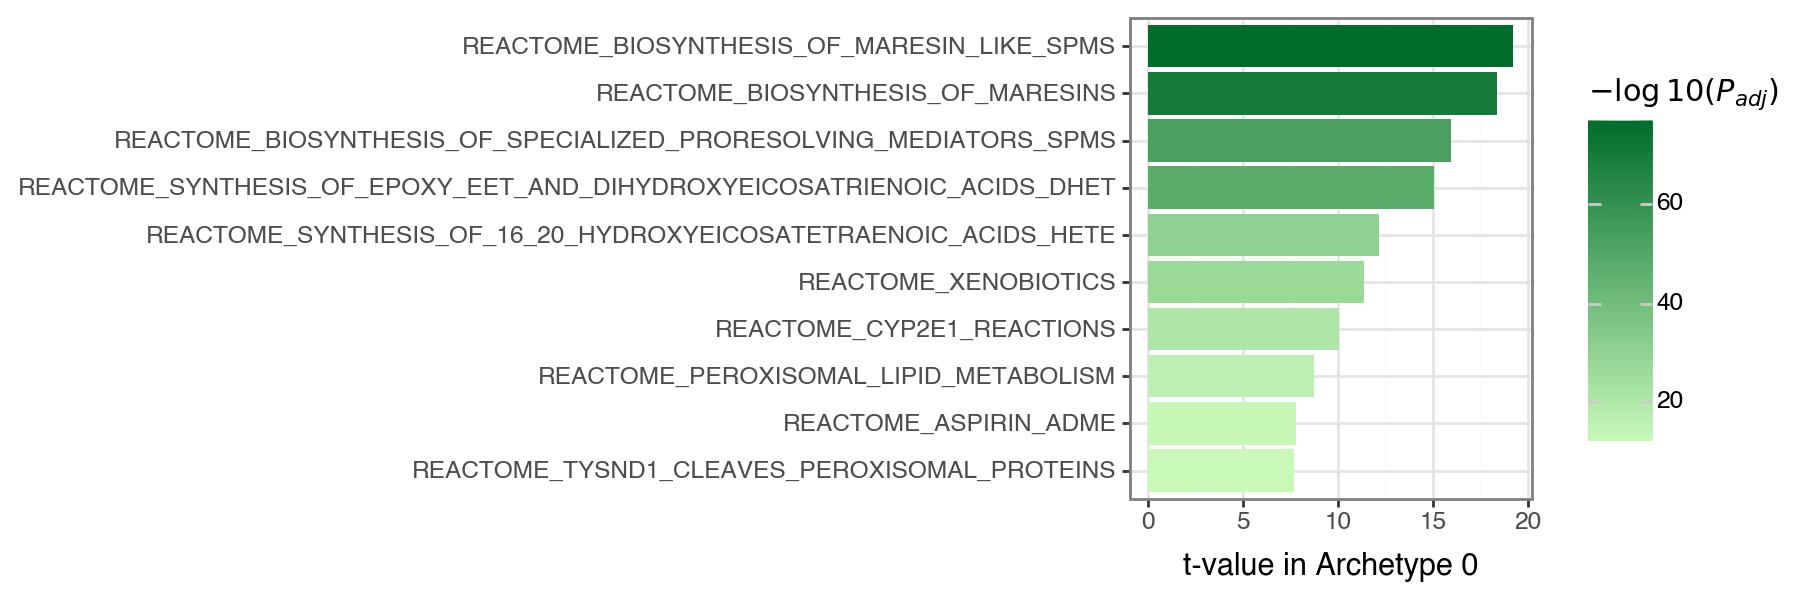

In [20]:
top_processes[arch_idx]["Process"] = pd.Categorical(
    top_processes[arch_idx]["Process"],
    categories=top_processes[arch_idx].sort_values(f"{arch_idx}", ascending=True)["Process"].to_list()
)
top_processes[arch_idx][f"neg_log10_pval_{arch_idx}"] = - np.log10(top_processes[arch_idx][f"pval_{arch_idx}"])

p = (
    pn.ggplot(top_processes[arch_idx])
    + pn.geom_col(pn.aes(x="Process", y=f"act_{arch_idx}", fill=f"neg_log10_pval_{arch_idx}"))
    + pn.coord_flip()
    + pn.theme_bw()
    + pn.theme(figure_size=(9, 3))
    + pn.labs(x="", y=f"t-value in Archetype {arch_idx}", fill="$-\log10(P_{adj})$")
    + pn.scale_fill_gradient(low="#c8f9b9", high="#006d2c")
)
p.show()

Then, we can decoupler's leading edge function to check for example which genes have a high weight for our archetype of interest, and are in the gene set for "REACTOME_XENOBIOTICS".

['Cyp2e1' 'Cyp2c29' 'Cyp2c50' 'Cyp1a2' 'Cyp2c37' 'Cyp2a5' 'Cyp2c38' 'Ahr']


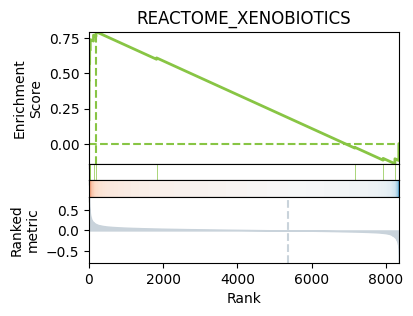

In [21]:
df = archetype_expression.T.copy()
df.columns = df.columns.astype(str)
_, le = dc.pl.leading_edge(
    df = df,
    net = msigdb_mouse,
    stat = str(arch_idx),
    name = "REACTOME_XENOBIOTICS"
)
print(le)

Another interesting thing we can do is to consider how gene expressions changes as a function of the distance to some archetype. To this end we can use the decoupler functions `dc.tl.rankby_order`, `dc.pp.bin_order`, and `dc.pl.order`.

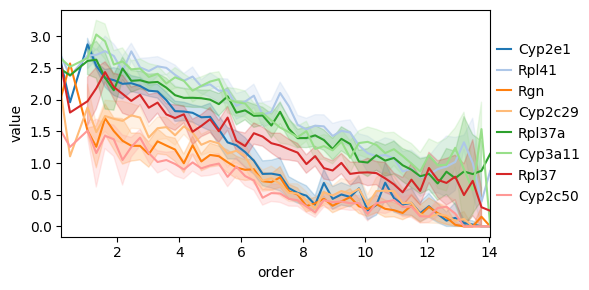

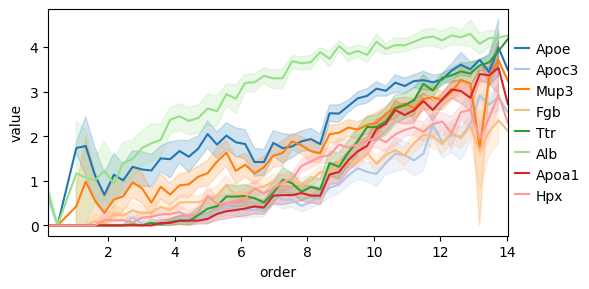

In [22]:
Z = pt.get_aa_result(adata, n_archetypes=4, delta=0)["Z"]
distances = cdist(
    adata.obsm[adata.uns["AA_config"]["obsm_key"]][:, adata.uns["AA_config"]["n_dimensions"]],
    Z
)
for idx in range(Z.shape[1]):
    adata.obs[f"dist_to_arch_{idx}"] = distances[:, idx]

genes_ordered = dc.tl.rankby_order(
    adata=adata,
    order=f"dist_to_arch_{arch_idx}",
    stat="spearmanr",
)
top_genes = genes_ordered.sort_values("stat").head(8)["name"].to_list()
bottom_genes = genes_ordered.sort_values("stat").tail(8)["name"].to_list()

top_genes_ordered = dc.pp.bin_order(
    adata=adata,
    order=f"dist_to_arch_{arch_idx}",
    names=top_genes,
     nbins=50,
)

bottom_genes_ordered = dc.pp.bin_order(
    adata=adata,
    order=f"dist_to_arch_{arch_idx}",
    names=bottom_genes,
     nbins=50,
)

dc.pl.order(
    df=top_genes_ordered,
    mode="line",
    figsize=(6, 3),
)

dc.pl.order(
    df=bottom_genes_ordered,
    mode="line",
    figsize=(6, 3),
)

Alternatively, we can use the quantile-based, distance-ranking gene-enrichment algorithm used in previous ParTI work {cite:p}`Adler2019,Korem2015,Hart2015` (see Supplementary Methods Section 4.4), which tests for genes whose expression is highest in the quantile bin closest to an archetype relative to a background (by default all remaining cells, with optional alternative contrasts such as closest versus furthest bins). This algorithm is implemented in `pt.compute_quantile_based_gene_enrichment`.

However note that this approach requires per-gene and per-archetype hypothesis testing across large numbers of cells and therefore scales less well than kernel-aggregated profiling.

In [23]:
gene_enrichment = pt.compute_quantile_based_gene_enrichment(adata, result_filters={"n_archetypes": 4, "delta": 0.0})
gene_enrichment.query("enriched").query(f"arch_idx=={arch_idx}").sort_values("pval_adj").head(6)

,arch_idx,gene,stat,pval,mean_diff,median_diff,mean_bin0,mean_rest,median_bin0,median_rest,max_in_bin0,pos_effect,pval_adj,signif,enriched
3779,0,Oat,306028.5,7.122084e-85,0.998351,1.177536,1.253019,0.254668,1.177536,0.000000,True,True,5.949789e-81,True,True
3801,0,Cyp2e1,315818.0,3.467040e-73,1.352518,2.014842,2.181629,0.829111,2.221061,0.206219,True,True,9.654550e-70,True,True
8235,0,Cyp2c50,289663.0,1.178018e-48,0.678192,0.807465,1.207931,0.529739,1.236465,0.429001,True,True,1.968233e-45,True,True
4263,0,Rpl41,293127.0,1.654406e-48,0.871232,0.713324,2.552605,1.681374,2.618408,1.905084,True,True,2.303484e-45,True,True
8227,0,Cyp2c29,290362.5,2.534837e-48,0.896444,1.324256,1.629166,0.732722,1.712150,0.387894,True,True,3.025147e-45,True,True
2009,0,Cyp4a10,272953.0,4.374906e-48,0.541017,0.781933,0.764036,0.223019,0.781933,0.000000,True,True,4.568496e-45,True,True


## Spatial Enrichment

As in {cite:p}`Adler2019`, we want to quantify where the archetypes locate in the tissue.

To that end we download a single-cell spatial data set from the liver from https://info.vizgen.com/mouse-liver-data (Vizgen MERFISH Mouse Liver Map January 2022). In particular we only need to download from `Liver1Slice1` the files `"cell_by_gene.csv", "cell_metadata.csv"` and place those in the folder `Liver1Slice1` in `data`.

Then, to quantify to which archetype any given cell is close to, we compute the enrichment of the archetype gene expression signatures in each cells' gene expression profile.

In [24]:
import sys
!{sys.executable} -m pip install --quiet squidpy

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


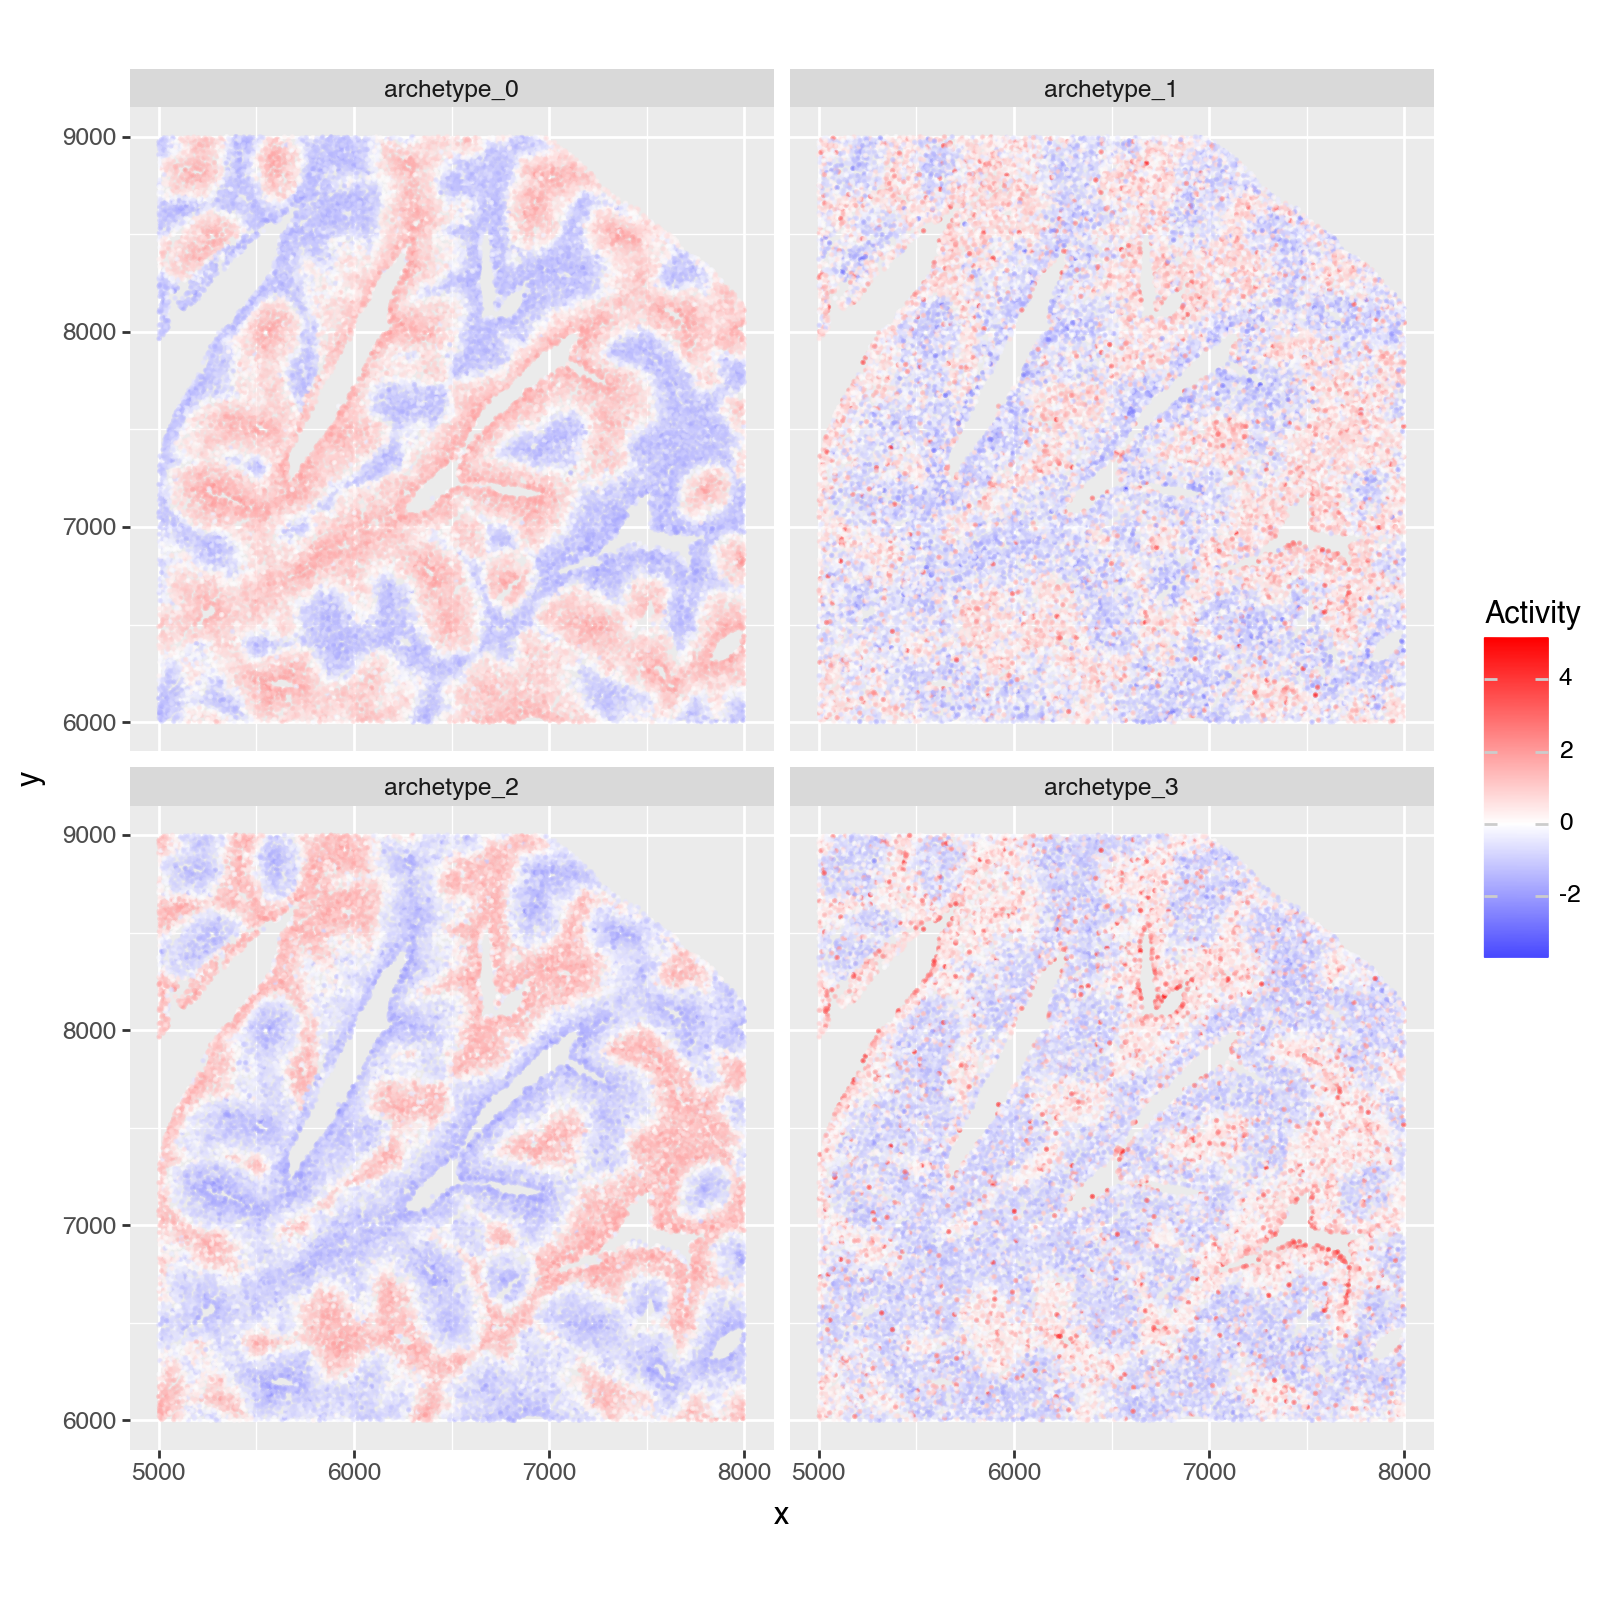

In [25]:
# only run if the data has actually been downloaded
if (Path(".") / "data" / "Liver1Slice1" / "Liver1Slice1_cell_by_gene.csv").exists() and (Path(".") / "data" / "Liver1Slice1" / "Liver1Slice1_cell_metadata.csv").exists():
    import squidpy as sq
    vizgen_adata = sq.read.vizgen(
        "./data/Liver1Slice1",
        counts_file="Liver1Slice1_cell_by_gene.csv",
        meta_file="Liver1Slice1_cell_metadata.csv",
    )
    vizgen_adata = vizgen_adata[:, vizgen_adata.var.index.isin(archetype_expression.columns.to_list())].copy()
    vizgen_adata = vizgen_adata[vizgen_adata.X.sum(axis=1).A1 > 200, :].copy()
    sc.pp.normalize_total(vizgen_adata)
    sc.pp.log1p(vizgen_adata)

    # create weights based on archetype expression profile
    archetype_expression_weights = (archetype_expression[vizgen_adata.var.index].copy()
                                    .reset_index(names="archetype")
                                    .melt(id_vars="archetype", value_name="weight", var_name="gene")
                                    )
    archetype_expression_weights = archetype_expression_weights.rename(columns={"archetype": "source", "gene": "target"})

    # compute the enrichment of the archetype gex profiles in the gex profiles of each cell
    dc.mt.ulm(data=vizgen_adata, net=archetype_expression_weights, verbose=False)

    # plotting one part
    plotting_df = vizgen_adata.obsm["score_ulm"].copy()
    plotting_df.columns = ["archetype_" + idx for idx in plotting_df.columns]
    plotting_df = plotting_df - plotting_df.mean()
    plotting_df = plotting_df / plotting_df.std()
    plotting_df["x"] = vizgen_adata.obsm["spatial"][:, 0]
    plotting_df["y"] = vizgen_adata.obsm["spatial"][:, 1]

    width = 3_000
    x_low = 5_000
    y_low = 6_000
    x_high = x_low + width
    y_high = y_low + width
    plotting_df = plotting_df.loc[(plotting_df["x"] > x_low) & (plotting_df["x"] < x_high) & (plotting_df["y"] > y_low) & (plotting_df["y"] < y_high)]

    plotting_df = plotting_df.melt(id_vars=["x", "y"], value_name="score", var_name="archetype")
    p = (pn.ggplot(plotting_df) 
        + pn.geom_point(pn.aes(x="x", y="y", color="score"), size=0.1, alpha=0.5) 
        + pn.scale_color_gradient2(low="blue", mid="white", high="red", midpoint=0)
        + pn.facet_wrap(facets="archetype", nrow=2, ncol=2)
        + pn.coord_equal() 
        + pn.theme(figure_size=(8, 8)) 
        + pn.labs(x="x", y="y", color="Activity")
        )
    p.show()

## Saving and Loading Results

See more details in the [Accessing And Saving Cached Results vignette](https://partipy.readthedocs.io/en/latest/notebooks/data_access.html) vignette. In brief: ParTIpy caches AA outputs with immutable `ArchetypeConfig` keys (a frozen Pydantic model), those objects keep the cache hashable inside `adata.uns`. HDF5 only accepts string keys, so `pt.write_h5ad` turns each config into a JSON string before writing, and `pt.read_h5ad` restores the original `ArchetypeConfig` objects so cached metrics still work after reloading.

In [26]:
pt.write_h5ad(adata, "adata.h5ad")
adata = pt.read_h5ad("adata.h5ad")
adata

AnnData object with n_obs × n_vars = 1999 × 8354
    obs: 'cell_type', 'zone', 'run_id', 'time_point', 'UMAP_X', 'UMAP_Y', 'weights_archetype_0', 'dist_to_arch_0', 'dist_to_arch_1', 'dist_to_arch_2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'AA_bootstrap', 'AA_cell_weights', 'AA_config', 'AA_pca', 'AA_results', 'AA_selection_metrics', 'AA_t_ratio', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'z_scaled'

## Session Info

In [27]:
import session_info2
print(session_info2.session_info(dependencies=True))

pandas	2.2.3
scanpy	1.11.2
plotnine	0.14.5
decoupler	2.0.6
numpy	2.2.6
scipy	1.15.2
partipy	0.2.0 (0.0.1)
anndata	0.11.4
squidpy	1.6.5
----	----
traitlets	5.14.3
zstandard	0.25.0
ptyprocess	0.7.0
cycler	0.12.1
dask	2024.11.2
imageio	2.37.0
narwhals	1.41.0
certifi	2025.4.26 (2025.04.26)
torch	2.10.0
dask-image	2024.5.3
spatialdata	0.4.0
cloudpickle	3.1.1
executing	2.2.0
idna	3.10
asttokens	3.0.0
ipython	9.2.0
numba	0.61.2
adjustText	1.3.0
legendkit	0.3.5
xarray	2024.11.0
xarray-schema	0.0.3
matplotlib	3.10.3
jaraco.classes	3.4.0
coverage	7.10.7
pydantic_core	2.41.1
PyYAML	6.0.2
seaborn	0.13.2
MarkupSafe	3.0.3
ipykernel	6.29.5
parso	0.8.4
llvmlite	0.44.0
matplotlib-inline	0.1.7
numcodecs	0.15.1
session-info2	0.1.2
natsort	8.4.0
scikit-image	0.25.2
pyparsing	3.2.3
igraph	0.11.8
datashader	0.18.1
scikit-learn	1.6.1
jaraco.functools	4.3.0
wrapt	1.17.2
attrs	25.3.0
platformdirs	4.3.8
kiwisolver	1.4.8
Jinja2	3.1.6
xarray-dataclasses	1.9.1
jupyter_core	5.8.1
more-itertools	10.7.0
decorator	5.2